In [98]:
# CHECK LIST
# Report Net monetary benefit [√]
# Relative mortality reduction [√]
# Factor consumption ratio [√]
# Report Incremental cost effectiveness ratio [√]
# Report quality adjusted life year [√]
# Report annual bleeding rate [√]
# Report annual joint hemorrhages [√]

# Value to report:
# Tornado diagram [ ]
# Onset of arthropathy [ ]
# Arthropathy progression and delayed onset [ ]

# OPTIONAL
# prevented_death_per_1000_patients [ ]
# Relative annual bleeding rate reduction [ ]
# Burden of disease [ ]

In [99]:
# IMPORTS | HELPER FUNCTIONS
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.optimize import curve_fit
from scipy.stats import ks_2samp
from statsmodels.nonparametric.smoothers_lowess import lowess

from app.domain.enums import HealthStates
from app.notebook.cache import resolve_cache
from app.notebook.dataframe_builders import columns, occupation_columns
from app.notebook.display import show
from app.persistence.context import ModelContext
from app.visualization.plots import apply_grid
from utils.logging import setup_root_logger
from utils.path_utils import get_project_root

palette = {
    "on-demand": "#1f77b4",
    "prophylaxis": "#ff7f0e",
}

logger = setup_root_logger()
root = get_project_root()
context = ModelContext.load()
psa_cache_path = resolve_cache("psa", root=root)
extended_cols = columns.extend(occupation_columns)
df = pl.read_parquet(psa_cache_path, columns=extended_cols)
# Rows with no extension are the "base" scenarios; ``is_null()`` is the
# polars equivalent of pandas ``isna()``.
df_base = df.filter(pl.col("extension").is_null())
regimes = df["regime"].unique().to_list()
scenarios = df["scenario"].unique().to_list()
states = [state.value for state in HealthStates]


# -----------------------------
# Formatting helpers
# -----------------------------


def mean_sd(x: pl.Series, digits: int = 2) -> str:
    return f"{x.mean():.{digits}f} ± {x.std():.{digits}f}"


def median_iqr(x: pl.Series, digits: int = 2) -> str:
    return (
        f"{x.median():.{digits}f} "
        f"[{x.quantile(0.25):.{digits}f}, {x.quantile(0.75):.{digits}f}]"
    )


def percent(x: pl.Series, digits: int = 2) -> float:
    return round(float(x.mean() * 100), digits)  # type: ignore


# Compact inline rendering (150 dpi) - keep inline images notebook-friendly.
from app.notebook.plot_style import apply_inline_style

apply_inline_style()

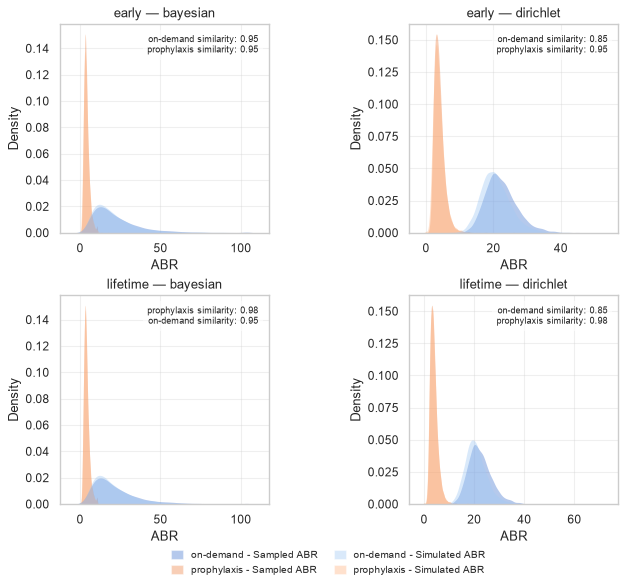

In [100]:
# plot abr distribution per base scenarios
@apply_grid(
    row_values=["early", "lifetime"],
    col_values=["bayesian", "dirichlet"],
    row_name="time_horizon",
    col_name="sampling_method",
    dataframe=df_base,
    figsize=(11, 8),
    gridspec_kw={"wspace": 0.05, "hspace": 0.30, "bottom": 0.13},
)
def plot_abr_and_bleeding(ax, sub, row_value, col_value, i, j):
    """
    Plot input ABR and outcome bleeding distributions per scenario using KDE
    """

    if sub.is_empty():
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=12, alpha=0.6)
        ax.set_axis_off()
        return

    # Palettes
    abr_palette = sns.color_palette("muted", n_colors=sub["regime"].n_unique())
    bleeding_palette = sns.color_palette("pastel", n_colors=sub["regime"].n_unique())
    regimes = sub["regime"].unique().to_list()

    # Plot KDE for sampled ABR
    sns.kdeplot(
        data=sub,
        x="sampled_abr",
        hue="regime",
        ax=ax,
        fill=True,
        alpha=0.4,
        palette=abr_palette,
        linewidth=0.0,
        legend=False,
    )

    # Plot KDE for annual bleeding rate
    sns.kdeplot(
        data=sub,
        x="annual_bleeding_rate",
        hue="regime",
        ax=ax,
        fill=True,
        alpha=0.4,
        palette=bleeding_palette,
        linewidth=0.0,
        legend=False,
    )

    ax.set_xlabel("ABR")
    ax.set_ylabel("Density")
    ax.set_title(f"{row_value} - {col_value}")
    ax.grid(True, alpha=0.3)

    # Build the legend handles for the figure-level legend drawn
    # below the grid. We do NOT call ``ax.legend`` here because the
    # in-axes legend overlaps the KDE curves.
    legend_elements = []
    for color, regime in zip(abr_palette, regimes):
        legend_elements.append(
            Patch(
                facecolor=color,
                alpha=0.4,
                label=f"{regime} - Sampled ABR",
            )
        )
    for color, regime in zip(bleeding_palette, regimes):
        legend_elements.append(
            Patch(
                facecolor=color,
                alpha=0.4,
                label=f"{regime} - Simulated ABR",
            )
        )
    # Stash the handles on the Axes so the wrapper can collect them.
    ax._legend_handles = legend_elements  # type: ignore[attr-defined]

    # Compute similarity for each regime using KS statistic
    sim_texts = []
    for regime in regimes:
        abr_data = sub.filter(sub["regime"] == regime).select("sampled_abr").to_series()
        bleed_data = (
            sub.filter(sub["regime"] == regime)
            .select("annual_bleeding_rate")
            .to_series()
        )
        ks_stat, _ = ks_2samp(abr_data, bleed_data)
        similarity = 1 - ks_stat  # type: ignore
        sim_texts.append(f"{regime} similarity: {similarity:.2f}")

    # Annotate similarity on the plot (lower-left, away from the
    # KDE peak at upper-right)
    ax.text(
        0.95,
        0.95,
        "\n".join(sim_texts),
        ha="right",
        va="top",
        transform=ax.transAxes,
        fontsize=8,
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"),
    )


fig, axes = plot_abr_and_bleeding()

# Draw a single figure-level legend below the grid, collecting the
# per-subplot handles. The first non-empty subplot's handles
# represent the union; the rest are identical because all subplots
# share the same regimes.
first_ax = axes[0][0] if hasattr(axes[0], "__len__") else axes[0]
handles = getattr(first_ax, "_legend_handles", None) or []
if handles:
    fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.005),
        ncol=2,
        frameon=False,
        fontsize=9,
        handlelength=1.2,
        handleheight=1.0,
        columnspacing=1.6,
    )
    fig.subplots_adjust(bottom=0.15)
plt.show()

In [101]:
# calibration report

from app.notebook.calibration import build_calibration_report

calibration_report = build_calibration_report(df_base)

display_cols = [
    "time_horizon",
    "sampling_method",
    "regime",
    "expected_abr",
    "realized_abr",
    "oe_ratio",
    "relative_error",
    "distribution_similarity_index",
    "pearson_r",
    "rmse",
    "mortality_rate",
    "calibration_status",
]

print(calibration_report.select(display_cols).with_columns(pl.col(pl.Float64).round(3)))
display(
    df.group_by(["regime", "is_absorbed"]).agg(
        pl.col("sampled_abr").mean(),
        pl.col("annual_bleeding_rate").mean(),
        pl.col("person_years").mean(),
    )
)
print("NOTE: structural under-realization due to cycle/event mechanics")
note = """
Bayesian parameter sampling introduced greater between-patient heterogeneity,
which amplified nonlinear interactions with event truncation and competing mortality,
leading to reduced calibration stability in high-intensity bleeding scenarios.
Dirichlet-based sampling produced more stable calibration due to implicit shrinkage of extreme parameter values."""
print(note)

shape: (8, 12)
┌────────────┬────────────┬────────────┬───────────┬───┬───────────┬───────┬───────────┬───────────┐
│ time_horiz ┆ sampling_m ┆ regime     ┆ expected_ ┆ … ┆ pearson_r ┆ rmse  ┆ mortality ┆ calibrati │
│ on         ┆ ethod      ┆ ---        ┆ abr       ┆   ┆ ---       ┆ ---   ┆ _rate     ┆ on_status │
│ ---        ┆ ---        ┆ str        ┆ ---       ┆   ┆ f64       ┆ f64   ┆ ---       ┆ ---       │
│ str        ┆ str        ┆            ┆ f64       ┆   ┆           ┆       ┆ f64       ┆ str       │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════╪═══════════╪═══════════╡
│ early      ┆ bayesian   ┆ on-demand  ┆ 22.577    ┆ … ┆ 0.985     ┆ 4.689 ┆ 1.0       ┆ Acceptabl │
│            ┆            ┆            ┆           ┆   ┆           ┆       ┆           ┆ e         │
│ early      ┆ bayesian   ┆ prophylaxi ┆ 3.871     ┆ … ┆ 0.881     ┆ 0.858 ┆ 1.0       ┆ Excellent │
│            ┆            ┆ s          ┆           ┆   ┆           ┆       ┆

regime,is_absorbed,sampled_abr,annual_bleeding_rate,person_years
str,bool,f64,f64,f64
"""prophylaxis""",true,3.863259,3.827276,37.095101
"""on-demand""",true,22.52422,20.324283,23.728415


NOTE: structural under-realization due to cycle/event mechanics

Bayesian parameter sampling introduced greater between-patient heterogeneity,
which amplified nonlinear interactions with event truncation and competing mortality,
leading to reduced calibration stability in high-intensity bleeding scenarios.
Dirichlet-based sampling produced more stable calibration due to implicit shrinkage of extreme parameter values.


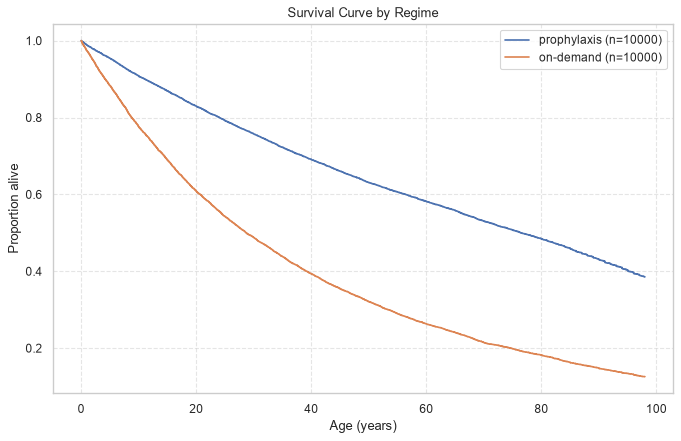

In [102]:
# SURVIVAL CURVE PLOT
plt.figure(figsize=(10, 6))


def plot_survival_curve(df: pl.DataFrame):
    for regime in regimes:
        df_r = df_base.filter(pl.col("regime") == regime)
        ma = (pl.col("time_horizon") == "lifetime") & (
            pl.col("sampling_method") == "bayesian"
        )
        observed_weeks = df_r.filter(ma).select("observed_cycles").to_series()

        max_weeks = int(observed_weeks.max() or 0)  # type: ignore
        survival = []

        for week in range(max_weeks):
            alive = int((observed_weeks > week).sum() or 0)
            survival.append(alive / observed_weeks.len())

        years = np.arange(max_weeks) / 52
        plt.step(
            years, survival, where="post", label=f"{regime} (n={observed_weeks.len()})"
        )
    plt.xlabel("Age (years)")
    plt.ylabel("Proportion alive")
    plt.title("Survival Curve by Regime")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()


plot_survival_curve(df=df_base)
plt.show()

In [103]:
# ICER comparison structure (pairs)
# -------------------------------------
from app.notebook.scenario_helpers import pair_scenarios

pairs = pair_scenarios(list(scenarios))
for pair in pairs:
    print(pair)

('lifetime on-demand bayesian', 'lifetime prophylaxis bayesian')
('early on-demand bayesian', 'early prophylaxis bayesian')
('lifetime on-demand bayesian weight_reduction_20', 'lifetime prophylaxis bayesian weight_reduction_20')
('early on-demand bayesian weight_reduction_20', 'early prophylaxis bayesian weight_reduction_20')
('lifetime on-demand bayesian weight_reduction_10', 'lifetime prophylaxis bayesian weight_reduction_10')
('early on-demand bayesian weight_reduction_30', 'early prophylaxis bayesian weight_reduction_30')
('early on-demand bayesian is_discounting', 'early prophylaxis bayesian is_discounting')
('early on-demand bayesian weight_reduction_10', 'early prophylaxis bayesian weight_reduction_10')
('lifetime on-demand bayesian is_discounting', 'lifetime prophylaxis bayesian is_discounting')
('lifetime on-demand dirichlet', 'lifetime prophylaxis dirichlet')
('lifetime on-demand bayesian weight_reduction_30', 'lifetime prophylaxis bayesian weight_reduction_30')
('early on-de

In [104]:
# Clinical (Bleeding Summary)
# -----------------------------
# The custom aggregators ``mean_sd`` / ``median_iqr`` are string
# formatters that have no polars expression equivalent, so we drop into
# pandas at the groupby boundary and convert back to polars.
import pandas as pd


def _group_with_callables(df: pl.DataFrame, by: str, aggs: dict) -> pl.DataFrame:
    """Run a pandas-style groupby with arbitrary callable aggregators
    and return a polars DataFrame.

    ``aggs`` is a mapping of ``{output_col: (source_col, func)}``. Each
    callable is applied to the source column per group; the result is
    a single value, so the per-group aggregation works.
    """
    pdf = df.to_pandas()
    out = pdf.groupby(by, as_index=False).agg(
        **{
            out_col: pd.NamedAgg(column=src, aggfunc=fn)
            for out_col, (src, fn) in aggs.items()
        }
    )
    return pl.from_pandas(out)


import polars as pl  # only used inside _group_with_callables

clinical_summary_df = _group_with_callables(
    df,
    by="scenario",
    aggs={
        "simulations": ("scenario", "size"),
        "qaly_mean": ("total_qaly", "mean"),
        "qaly_mean_sd": ("total_qaly", mean_sd),
        "qaly_median_iqr": ("total_qaly", median_iqr),
        "pettersson_mean_sd": ("pettersson_score", mean_sd),
        "pettersson_median_iqr": ("pettersson_score", median_iqr),
    },
)

discount_pairs = {
    "early on-demand bayesian": "early on-demand bayesian is_discounting",
    "early prophylaxis bayesian": "early prophylaxis bayesian is_discounting",
    "lifetime on-demand bayesian": "lifetime on-demand bayesian is_discounting",
    "lifetime prophylaxis bayesian": "lifetime prophylaxis bayesian is_discounting",
}

print("Relative retained:")
for base, comp in discount_pairs.items():
    base_df = clinical_summary_df.filter(pl.col("scenario") == base)
    comp_df = clinical_summary_df.filter(pl.col("scenario") == comp)

    undiscounted = base_df.select("qaly_mean").item()
    discounted = comp_df.select("qaly_mean").item()

    retained = discounted / undiscounted

    print(f"{base} | {comp}: = {retained:.2%}")

print("\nNOTE: Prophylaxis major benefits are long-term preservation effects.")

show(clinical_summary_df, "Clinical outcomes")

bleeding_summary_df = _group_with_callables(
    df,
    by="scenario",
    aggs={
        "abr_mean_sd": ("annual_bleeding_rate", mean_sd),
        "abr_median_iqr": ("annual_bleeding_rate", median_iqr),
        "sbr_mean_sd": ("spontaneous_bleeding_rate", mean_sd),
        "sbr_median_iqr": ("spontaneous_bleeding_rate", median_iqr),
        "ajbr_mean_sd": ("annual_joint_bleeding_rate", mean_sd),
        "ajbr_median_iqr": ("annual_joint_bleeding_rate", median_iqr),
        "altb_mean_sd": ("annual_life_threatening_rate", mean_sd),
        "altb_median_iqr": ("annual_life_threatening_rate", median_iqr),
        "total_bleeding_events": ("bleeding_events", "sum"),
        "total_joint_bleeding_events": ("joint_bleeding_events", "sum"),
        "total_person_years": ("person_years", "sum"),
    },
).with_columns(
    (pl.col("total_bleeding_events") / pl.col("total_person_years"))
    .round(3)
    .alias("cohort_abr"),
    (pl.col("total_joint_bleeding_events") / pl.col("total_person_years"))
    .round(3)
    .alias("cohort_ajbr"),
)

show(
    bleeding_summary_df,
    "Bleeding outcome",
    {"cohort_abr": "{:.2f}", "cohort_ajbr": "{:.2f}"},
    store=True,
    options={
        "override": False,
        "storage": {
            "excel_writer": root
            / "app"
            / "outputs"
            / "sheets"
            / "bleeding_summary.xlsx",
            "index": False,
        },
    },
)

Relative retained:
early on-demand bayesian | early on-demand bayesian is_discounting: = 80.13%
early prophylaxis bayesian | early prophylaxis bayesian is_discounting: = 79.50%
lifetime on-demand bayesian | lifetime on-demand bayesian is_discounting: = 35.80%
lifetime prophylaxis bayesian | lifetime prophylaxis bayesian is_discounting: = 27.41%

NOTE: Prophylaxis major benefits are long-term preservation effects.


,scenario,simulations,qaly_mean,qaly_mean_sd,qaly_median_iqr,pettersson_mean_sd,pettersson_median_iqr
0,early on-demand bayesian,10000,6.771817,6.77 ± 2.15,"7.51 [6.55, 8.08]",9.93 ± 7.24,"8.00 [5.00, 13.00]"
1,early on-demand bayesian is_discounting,10000,5.426219,5.43 ± 1.63,"5.96 [5.22, 6.41]",9.96 ± 7.27,"8.00 [5.00, 13.00]"
2,early on-demand bayesian weight_reduction_10,10000,6.773226,6.77 ± 2.15,"7.51 [6.55, 8.09]",9.96 ± 7.31,"8.00 [5.00, 13.00]"
3,early on-demand bayesian weight_reduction_20,10000,6.778801,6.78 ± 2.15,"7.51 [6.58, 8.09]",9.95 ± 7.24,"8.00 [5.00, 13.00]"
4,early on-demand bayesian weight_reduction_30,10000,6.777391,6.78 ± 2.15,"7.52 [6.56, 8.08]",9.94 ± 7.23,"8.00 [5.00, 13.00]"
5,early on-demand dirichlet,10000,6.601774,6.60 ± 2.00,"7.40 [6.94, 7.68]",10.49 ± 4.15,"11.00 [9.00, 13.00]"
6,early prophylaxis bayesian,10000,8.454585,8.45 ± 1.61,"8.89 [8.48, 9.18]",1.67 ± 1.13,"1.00 [1.00, 2.00]"
7,early prophylaxis bayesian is_discounting,10000,6.721318,6.72 ± 1.20,"7.03 [6.72, 7.26]",1.67 ± 1.13,"1.00 [1.00, 2.00]"
8,early prophylaxis bayesian weight_reduction_10,10000,8.481882,8.48 ± 1.57,"8.89 [8.49, 9.18]",1.67 ± 1.12,"1.00 [1.00, 2.00]"
9,early prophylaxis bayesian weight_reduction_20,10000,8.465882,8.47 ± 1.60,"8.89 [8.48, 9.18]",1.67 ± 1.13,"1.00 [1.00, 2.00]"


,scenario,abr_mean_sd,abr_median_iqr,sbr_mean_sd,sbr_median_iqr,ajbr_mean_sd,ajbr_median_iqr,altb_mean_sd,altb_median_iqr,total_bleeding_events,total_joint_bleeding_events,total_person_years,cohort_abr,cohort_ajbr
0,early on-demand bayesian,20.24 ± 13.04,"17.04 [11.00, 26.00]",4.19 ± 2.87,"3.50 [2.20, 5.40]",15.41 ± 10.06,"12.90 [8.30, 19.80]",0.64 ± 1.22,"0.40 [0.20, 0.70]",1711115,1311093,87874.384615,19.47,14.92
1,early on-demand bayesian is_discounting,20.24 ± 13.01,"17.05 [11.09, 26.00]",4.17 ± 2.87,"3.50 [2.20, 5.40]",15.42 ± 10.06,"13.00 [8.30, 19.90]",0.64 ± 1.25,"0.40 [0.20, 0.70]",1713824,1313906,87889.788462,19.50,14.95
2,early on-demand bayesian weight_reduction_10,20.23 ± 13.01,"17.00 [11.06, 26.00]",4.18 ± 2.86,"3.50 [2.20, 5.40]",15.42 ± 10.04,"12.90 [8.30, 19.92]",0.63 ± 1.16,"0.40 [0.20, 0.70]",1714757,1314100,87926.076923,19.50,14.95
3,early on-demand bayesian weight_reduction_20,20.25 ± 13.05,"17.00 [11.10, 26.00]",4.18 ± 2.85,"3.50 [2.20, 5.38]",15.43 ± 10.08,"12.95 [8.30, 19.90]",0.64 ± 1.31,"0.40 [0.20, 0.70]",1711944,1312474,87953.807692,19.46,14.92
4,early on-demand bayesian weight_reduction_30,20.24 ± 13.03,"17.03 [11.10, 26.00]",4.18 ± 2.88,"3.50 [2.20, 5.40]",15.41 ± 10.06,"12.90 [8.30, 19.90]",0.64 ± 1.29,"0.40 [0.20, 0.70]",1711079,1311449,87903.461538,19.46,14.92
5,early on-demand dirichlet,20.57 ± 4.51,"20.20 [17.50, 23.20]",4.25 ± 1.46,"4.14 [3.30, 5.10]",15.71 ± 3.80,"15.40 [13.20, 17.90]",0.61 ± 1.11,"0.43 [0.28, 0.70]",1795992,1381059,87660.519231,20.49,15.76
6,early prophylaxis bayesian,3.82 ± 1.81,"3.50 [2.60, 4.70]",0.83 ± 0.51,"0.70 [0.50, 1.10]",2.86 ± 1.37,"2.60 [1.90, 3.50]",0.14 ± 0.59,"0.10 [0.00, 0.20]",360410,272195,95263.538462,3.78,2.86
7,early prophylaxis bayesian is_discounting,3.82 ± 1.79,"3.50 [2.60, 4.70]",0.83 ± 0.49,"0.70 [0.50, 1.10]",2.86 ± 1.37,"2.60 [1.90, 3.50]",0.14 ± 0.55,"0.10 [0.00, 0.20]",360665,272409,95323.730769,3.78,2.86
8,early prophylaxis bayesian weight_reduction_10,3.82 ± 1.79,"3.50 [2.60, 4.70]",0.83 ± 0.50,"0.70 [0.50, 1.10]",2.86 ± 1.37,"2.60 [1.90, 3.50]",0.13 ± 0.55,"0.10 [0.00, 0.20]",361639,272846,95532.730769,3.79,2.86
9,early prophylaxis bayesian weight_reduction_20,3.82 ± 1.79,"3.50 [2.60, 4.70]",0.83 ± 0.50,"0.70 [0.50, 1.10]",2.86 ± 1.38,"2.60 [1.90, 3.50]",0.13 ± 0.53,"0.10 [0.00, 0.20]",360654,272285,95356.346154,3.78,2.85


[18:01:22] WARNING  File C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\sheets\bleeding_summary.xlsx already exists. DataFrame not stored to avoid overwriting.


In [105]:
# Mortality & Life expectancy
# -----------------------------
mortality_summary_df = _group_with_callables(
    df,
    by="scenario",
    aggs={
        "person_years_mean_sd": ("person_years", mean_sd),
        "person_years_median_iqr": ("person_years", median_iqr),
        "lost_person_years_mean_sd": ("lost_person_years", mean_sd),
        "lost_person_years_median_iqr": ("lost_person_years", median_iqr),
        "lost_life_expectancy_median_iqr": (
            "lost_person_year_life_expectancy",
            median_iqr,
        ),
        "absorbed_percent": ("is_absorbed", percent),
    },
)

show(
    mortality_summary_df,
    "Mortality and life expectancy",
    store=True,
    options={
        "override": False,
        "storage": {
            "excel_writer": root
            / "app"
            / "outputs"
            / "sheets"
            / "mortality_summary.xlsx",
            "index": False,
        },
    },
)

,scenario,person_years_mean_sd,person_years_median_iqr,lost_person_years_mean_sd,lost_person_years_median_iqr,lost_life_expectancy_median_iqr,absorbed_percent
0,early on-demand bayesian,8.79 ± 2.62,"10.00 [10.00, 10.00]",1.21 ± 2.62,"0.00 [0.00, 0.00]","62.00 [62.00, 62.00]",100.000000
1,early on-demand bayesian is_discounting,8.79 ± 2.61,"10.00 [10.00, 10.00]",1.21 ± 2.61,"0.00 [0.00, 0.00]","62.00 [62.00, 62.00]",100.000000
2,early on-demand bayesian weight_reduction_10,8.79 ± 2.61,"10.00 [10.00, 10.00]",1.21 ± 2.61,"0.00 [0.00, 0.00]","62.00 [62.00, 62.00]",100.000000
3,early on-demand bayesian weight_reduction_20,8.80 ± 2.61,"10.00 [10.00, 10.00]",1.20 ± 2.61,"0.00 [0.00, 0.00]","62.00 [62.00, 62.00]",100.000000
4,early on-demand bayesian weight_reduction_30,8.79 ± 2.61,"10.00 [10.00, 10.00]",1.21 ± 2.61,"0.00 [0.00, 0.00]","62.00 [62.00, 62.00]",100.000000
5,early on-demand dirichlet,8.77 ± 2.64,"10.00 [10.00, 10.00]",1.23 ± 2.64,"0.00 [0.00, 0.00]","62.00 [62.00, 62.00]",100.000000
6,early prophylaxis bayesian,9.53 ± 1.74,"10.00 [10.00, 10.00]",0.47 ± 1.74,"0.00 [0.00, 0.00]","62.00 [62.00, 62.00]",100.000000
7,early prophylaxis bayesian is_discounting,9.53 ± 1.73,"10.00 [10.00, 10.00]",0.47 ± 1.73,"0.00 [0.00, 0.00]","62.00 [62.00, 62.00]",100.000000
8,early prophylaxis bayesian weight_reduction_10,9.55 ± 1.69,"10.00 [10.00, 10.00]",0.45 ± 1.69,"0.00 [0.00, 0.00]","62.00 [62.00, 62.00]",100.000000
9,early prophylaxis bayesian weight_reduction_20,9.54 ± 1.73,"10.00 [10.00, 10.00]",0.46 ± 1.73,"0.00 [0.00, 0.00]","62.00 [62.00, 62.00]",100.000000


[18:01:22] WARNING  File C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\sheets\mortality_summary.xlsx already exists. DataFrame not stored to avoid overwriting.


In [106]:
# Resource Utilization
# -----------------------------
factor_summary_df = _group_with_callables(
    df,
    by="scenario",
    aggs={
        "total_factor_mean_sd": ("total_factor", mean_sd),
        "total_factor_median_iqr": ("total_factor", median_iqr),
        "min_total_factor": ("total_factor", "min"),
        "max_total_factor": ("total_factor", "max"),
        "total_cost_mean": ("total_cost", "mean"),
    },
)

print("Relative retained:")
for base, comp in discount_pairs.items():
    base_df = factor_summary_df.filter(pl.col("scenario") == base)
    comp_df = factor_summary_df.filter(pl.col("scenario") == comp)

    undiscounted = base_df.select("total_cost_mean").item()
    discounted = comp_df.select("total_cost_mean").item()

    retained = discounted / undiscounted

    print(f"{base} | {comp}: = {retained:.2%}")

print("\nNOTE: Most economic burden in hemophilia is long-term, not immediate.")

show(
    factor_summary_df,
    "Resource Utilization",
    {"total_cost_mean": "{:,.0f} IRR"},
    store=True,
    options={
        "override": False,
        "storage": {
            "excel_writer": root / "app" / "outputs" / "sheets" / "factor_summary.xlsx",
            "index": False,
        },
    },
)

Relative retained:
early on-demand bayesian | early on-demand bayesian is_discounting: = 72.04%
early prophylaxis bayesian | early prophylaxis bayesian is_discounting: = 71.77%
lifetime on-demand bayesian | lifetime on-demand bayesian is_discounting: = 24.85%
lifetime prophylaxis bayesian | lifetime prophylaxis bayesian is_discounting: = 16.84%

NOTE: Most economic burden in hemophilia is long-term, not immediate.


,scenario,total_factor_mean_sd,total_factor_median_iqr,min_total_factor,max_total_factor,total_cost_mean
0,early on-demand bayesian,433861.69 ± 315779.37,"368557.50 [214501.00, 582523.50]",0,2515866,"25,088,399,976 IRR"
1,early on-demand bayesian is_discounting,435453.11 ± 319812.37,"370524.50 [211874.50, 584101.50]",0,2805124,"18,074,334,822 IRR"
2,early on-demand bayesian weight_reduction_10,391692.88 ± 288746.64,"329236.00 [191250.75, 523841.25]",0,2329174,"22,650,176,473 IRR"
3,early on-demand bayesian weight_reduction_20,347078.29 ± 253055.21,"292668.50 [171933.25, 462871.50]",0,1972373,"20,069,846,326 IRR"
4,early on-demand bayesian weight_reduction_30,303568.79 ± 220866.33,"255425.50 [149546.75, 403909.75]",0,1578059,"17,553,744,907 IRR"
5,early on-demand dirichlet,460626.94 ± 201421.97,"488102.50 [372232.25, 589946.25]",0,1222921,"26,635,983,724 IRR"
6,early prophylaxis bayesian,1285977.64 ± 672613.46,"1201663.00 [818871.00, 1661538.00]",1707,5475314,"74,341,325,029 IRR"
7,early prophylaxis bayesian is_discounting,1298845.58 ± 681365.69,"1216899.00 [824881.25, 1686586.75]",1649,5460680,"53,353,892,873 IRR"
8,early prophylaxis bayesian weight_reduction_10,1161186.43 ± 600888.94,"1087611.00 [740328.75, 1505601.00]",469,4515598,"67,127,004,674 IRR"
9,early prophylaxis bayesian weight_reduction_20,1030703.18 ± 536310.87,"966766.00 [657834.50, 1338590.00]",565,4070307,"59,584,325,332 IRR"


[18:01:22] WARNING  File C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\sheets\factor_summary.xlsx already exists. DataFrame not stored to avoid overwriting.


In [107]:
# Health State Occupation
# -----------------------------
weekly_state_df = (
    df.group_by("scenario")
    .agg(
        healthy=pl.col("healthy_share").mean(),
        bleeding=pl.col("bleeding_share").mean(),
        hemarthrosis=pl.col("hemarthrosis_share").mean(),
        lt_bleeding=pl.col("lt_bleeding_share").mean(),
        death=pl.col("death_share").mean(),
    )
    .with_columns(
        pl.col("healthy").round(3),
        pl.col("bleeding").round(3),
        pl.col("hemarthrosis").round(3),
        pl.col("lt_bleeding").round(3),
        pl.col("death").round(3),
    )
)

show(
    weekly_state_df,
    "Health State Occupation",
    store=True,
    options={
        "override": False,
        "storage": {
            "excel_writer": root / "app" / "outputs" / "sheets" / "weekly_state.xlsx",
            "index": False,
        },
    },
)

,scenario,healthy,bleeding,hemarthrosis,lt_bleeding,death
0,early on-demand bayesian,0.676000,0.075000,0.239000,0.010000,0.000000
1,early on-demand bayesian weight_reduction_30,0.676000,0.075000,0.239000,0.010000,0.000000
2,early prophylaxis dirichlet,0.929000,0.016000,0.053000,0.003000,0.000000
3,early prophylaxis bayesian weight_reduction_10,0.929000,0.016000,0.053000,0.002000,0.000000
4,early prophylaxis bayesian weight_reduction_20,0.929000,0.016000,0.053000,0.003000,0.000000
5,early prophylaxis bayesian,0.928000,0.016000,0.053000,0.003000,0.000000
6,early on-demand bayesian is_discounting,0.676000,0.075000,0.239000,0.010000,0.000000
7,lifetime prophylaxis bayesian weight_reduction_10,0.928000,0.016000,0.053000,0.003000,0.000000
8,early on-demand dirichlet,0.655000,0.078000,0.257000,0.010000,0.000000
9,early prophylaxis bayesian is_discounting,0.929000,0.016000,0.053000,0.003000,0.000000


[18:01:22] WARNING  File C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\sheets\weekly_state.xlsx already exists. DataFrame not stored to avoid overwriting.


In [108]:
# Cohort-level survival proxy metrics
# -------------------------------------
survival_df = (
    df.group_by("scenario")
    .agg(
        simulations=pl.len(),
        absorbed_rate=pl.col("is_absorbed").mean(),
        person_years=pl.col("person_years").sum(),
        lost_person_years=pl.col("lost_person_years").sum(),
    )
    .with_columns(
        survival_efficiency=(
            pl.col("person_years")
            / (pl.col("person_years") + pl.col("lost_person_years"))
        )
    )
)

# Pairwise survival comparison
rows = []

for base, comp in pairs:
    base_row = survival_df.filter(pl.col("scenario") == base).row(0, named=True)
    comp_row = survival_df.filter(pl.col("scenario") == comp).row(0, named=True)

    base_eff = base_row["survival_efficiency"]
    comp_eff = comp_row["survival_efficiency"]

    delta_eff = comp_eff - base_eff
    rr = comp_eff / base_eff if base_eff != 0 else np.nan

    rows.append(
        {
            "comparison": f"{comp} vs {base}",
            "base_survival_efficiency": base_eff,
            "comp_survival_efficiency": comp_eff,
            "absolute_survival_gain": delta_eff,
            "relative_survival_ratio": rr,
            "relative_survival_gain_%": float((rr - 1) * 100),
            "absorbed_rate_base": base_row["absorbed_rate"],
            "absorbed_rate_comp": comp_row["absorbed_rate"],
        }
    )

mortality_proxy_df = pl.DataFrame(rows)

show(
    mortality_proxy_df,
    "Pairwise Survival Efficiency Comparison",
    {
        "base_survival_efficiency": "{:.3f}",
        "comp_survival_efficiency": "{:.3f}",
        "absolute_survival_gain": "{:+.3f}",
        "relative_survival_ratio": "{:.3f}",
        "relative_survival_gain_%": "{:+.1f}",
        "absorbed_rate_base": "{:.2%}",
        "absorbed_rate_comp": "{:.2%}",
    },
    store=True,
    options={
        "override": False,
        "storage": {
            "excel_writer": root
            / "app"
            / "outputs"
            / "sheets"
            / "mortality_proxy.xlsx",
            "index": False,
        },
    },
)

,comparison,base_survival_efficiency,comp_survival_efficiency,absolute_survival_gain,relative_survival_ratio,relative_survival_gain_%,absorbed_rate_base,absorbed_rate_comp
0,lifetime prophylaxis bayesian vs lifetime on-demand bayesian,0.400,0.659,+0.259,1.648,+64.8,100.00%,100.00%
1,early prophylaxis bayesian vs early on-demand bayesian,0.879,0.953,+0.074,1.084,+8.4,100.00%,100.00%
2,lifetime prophylaxis bayesian weight_reduction_20 vs lifetime on-demand bayesian weight_reduction_20,0.399,0.660,+0.260,1.651,+65.1,100.00%,100.00%
3,early prophylaxis bayesian weight_reduction_20 vs early on-demand bayesian weight_reduction_20,0.880,0.954,+0.074,1.084,+8.4,100.00%,100.00%
4,lifetime prophylaxis bayesian weight_reduction_10 vs lifetime on-demand bayesian weight_reduction_10,0.399,0.662,+0.263,1.659,+65.9,100.00%,100.00%
5,early prophylaxis bayesian weight_reduction_30 vs early on-demand bayesian weight_reduction_30,0.879,0.954,+0.075,1.086,+8.6,100.00%,100.00%
6,early prophylaxis bayesian is_discounting vs early on-demand bayesian is_discounting,0.879,0.953,+0.074,1.085,+8.5,100.00%,100.00%
7,early prophylaxis bayesian weight_reduction_10 vs early on-demand bayesian weight_reduction_10,0.879,0.955,+0.076,1.087,+8.7,100.00%,100.00%
8,lifetime prophylaxis bayesian is_discounting vs lifetime on-demand bayesian is_discounting,0.400,0.659,+0.259,1.647,+64.7,100.00%,100.00%
9,lifetime prophylaxis dirichlet vs lifetime on-demand dirichlet,0.370,0.661,+0.291,1.788,+78.8,100.00%,100.00%


[18:01:22] WARNING  File C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\app\outputs\sheets\mortality_proxy.xlsx already exists. DataFrame not stored to avoid overwriting.


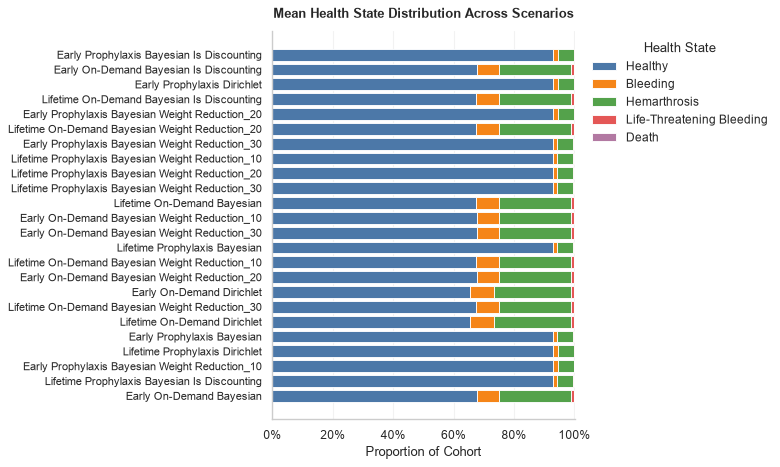

In [109]:
# Mean Health State Distribution Across Scenarios
from matplotlib.ticker import PercentFormatter

label_map = {
    "healthy": "Healthy",
    "bleeding": "Bleeding",
    "hemarthrosis": "Hemarthrosis",
    "lt_bleeding": "Life-Threatening Bleeding",
    "death": "Death",
}

# Polars equivalent of pandas ``melt`` is ``unpivot``.
long_df = weekly_state_df.unpivot(
    index="scenario",
    on=states,
    variable_name="health_state",
    value_name="proportion",
).with_columns(
    pl.col("health_state").replace_strict(label_map).alias("health_state"),
    pl.col("scenario")
    .str.replace("_", " ")
    .str.to_titlecase()
    .alias("scenario"),
)

# Manual pivot: average proportion per (scenario, health_state).
pivoted = (
    long_df.group_by(["scenario", "health_state"])
    .agg(pl.col("proportion").mean().alias("proportion"))
    .pivot(on="health_state", index="scenario", values="proportion")
    .fill_null(0.0)
)

state_order = [
    "Healthy",
    "Bleeding",
    "Hemarthrosis",
    "Life-Threatening Bleeding",
    "Death",
]

# Reorder columns. Polars ``select`` keeps only the listed columns in
# the order given.
pivoted = pivoted.select(["scenario", *state_order]).with_columns(
    pl.all().exclude("scenario").clip(lower_bound=0.0)
)

colors = {
    "Healthy": "#4C78A8",
    "Bleeding": "#F58518",
    "Hemarthrosis": "#54A24B",
    "Life-Threatening Bleeding": "#E45756",
    "Death": "#B279A2",
}

fig, ax = plt.subplots(figsize=(10, 6))

y = np.arange(pivoted.height)
left = np.zeros(pivoted.height)

for state in state_order:
    values = pivoted[state].to_numpy()

    ax.barh(
        y,
        values,
        left=left,
        label=state,
        color=colors[state],
        edgecolor="white",
        linewidth=0.8,
    )

    left += values

ax.set_yticks(y)
ax.set_yticklabels(pivoted["scenario"].to_list(), fontsize=10)

ax.set_xlabel("Proportion of Cohort")
ax.set_title("Mean Health State Distribution Across Scenarios", pad=12, weight="bold")

ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax.grid(axis="x", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Health State",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()


In [110]:
# ABR REDUCTION TABLE
# =====================================================

abr_results = []

for base, comp in pairs:
    base_row = (
        bleeding_summary_df.filter(pl.col("scenario") == base)
        .select("cohort_abr")
        .item()
    )

    comp_row = (
        bleeding_summary_df.filter(pl.col("scenario") == comp)
        .select("cohort_abr")
        .item()
    )

    absolute_reduction = base_row - comp_row
    relative_reduction = absolute_reduction / base_row

    abr_results.append(
        {
            "base_scenario": base,
            "comparison_scenario": comp,
            "base_cohort_abr": round(base_row, 3),
            "comparison_cohort_abr": round(comp_row, 3),
            "absolute_abr_reduction": round(absolute_reduction, 3),
            "relative_abr_reduction": f"{relative_reduction:.2%}",
        }
    )

abr_reduction_df = pl.DataFrame(abr_results)

show(
    abr_reduction_df,
    "Relative and Absolute ABR Reduction",
    {
        "base_cohort_abr": "{:.3f}",
        "comparison_cohort_abr": "{:.3f}",
        "absolute_abr_reduction": "{:.3f}",
    },
)

# =====================================================
# FACTOR CONSUMPTION REDUCTION TABLE
# =====================================================

factor_results = []

for base, comp in pairs:
    base_factor = df.filter(pl.col("scenario") == base)["total_factor"].mean()
    comp_factor = df.filter(pl.col("scenario") == comp)["total_factor"].mean()

    absolute_reduction = base_factor - comp_factor  # type: ignore

    relative_reduction = absolute_reduction / base_factor  # type: ignore

    factor_results.append(
        {
            "base_scenario": base,
            "comparison_scenario": comp,
            "base_factor_mean": round(base_factor, 0),  # type: ignore
            "comparison_factor_mean": round(comp_factor, 0),  # type: ignore
            "absolute_factor_reduction": round(absolute_reduction, 0),  # type: ignore
            "relative_factor_reduction": f"{relative_reduction:.2%}",
        }
    )

factor_reduction_df = pl.DataFrame(factor_results)

show(
    factor_reduction_df,
    "Relative and Absolute Factor Consumption Reduction",
    {
        "absolute_factor_reduction": "{:,.0f} U",
        "comparison_factor_mean": "{:,.0f} U",
        "base_factor_mean": "{:,.0f} U",
    },
)

,base_scenario,comparison_scenario,base_cohort_abr,comparison_cohort_abr,absolute_abr_reduction,relative_abr_reduction
0,lifetime on-demand bayesian,lifetime prophylaxis bayesian,16.667,3.696,12.971,77.82%
1,early on-demand bayesian,early prophylaxis bayesian,19.472,3.783,15.689,80.57%
2,lifetime on-demand bayesian weight_reduction_20,lifetime prophylaxis bayesian weight_reduction_20,16.752,3.697,13.055,77.93%
3,early on-demand bayesian weight_reduction_20,early prophylaxis bayesian weight_reduction_20,19.464,3.782,15.682,80.57%
4,lifetime on-demand bayesian weight_reduction_10,lifetime prophylaxis bayesian weight_reduction_10,16.771,3.702,13.069,77.93%
5,early on-demand bayesian weight_reduction_30,early prophylaxis bayesian weight_reduction_30,19.465,3.784,15.681,80.56%
6,early on-demand bayesian is_discounting,early prophylaxis bayesian is_discounting,19.500,3.784,15.716,80.59%
7,early on-demand bayesian weight_reduction_10,early prophylaxis bayesian weight_reduction_10,19.502,3.785,15.717,80.59%
8,lifetime on-demand bayesian is_discounting,lifetime prophylaxis bayesian is_discounting,16.763,3.699,13.064,77.93%
9,lifetime on-demand dirichlet,lifetime prophylaxis dirichlet,20.189,3.660,16.529,81.87%


,base_scenario,comparison_scenario,base_factor_mean,comparison_factor_mean,absolute_factor_reduction,relative_factor_reduction
0,lifetime on-demand bayesian,lifetime prophylaxis bayesian,"3,745,244 U","21,043,645 U","-17,298,401 U",-461.88%
1,early on-demand bayesian,early prophylaxis bayesian,"433,862 U","1,285,978 U","-852,116 U",-196.40%
2,lifetime on-demand bayesian weight_reduction_20,lifetime prophylaxis bayesian weight_reduction_20,"2,999,219 U","17,025,008 U","-14,025,789 U",-467.65%
3,early on-demand bayesian weight_reduction_20,early prophylaxis bayesian weight_reduction_20,"347,078 U","1,030,703 U","-683,625 U",-196.97%
4,lifetime on-demand bayesian weight_reduction_10,lifetime prophylaxis bayesian weight_reduction_10,"3,380,260 U","19,086,165 U","-15,705,905 U",-464.64%
5,early on-demand bayesian weight_reduction_30,early prophylaxis bayesian weight_reduction_30,"303,569 U","897,298 U","-593,729 U",-195.58%
6,early on-demand bayesian is_discounting,early prophylaxis bayesian is_discounting,"435,453 U","1,298,846 U","-863,392 U",-198.27%
7,early on-demand bayesian weight_reduction_10,early prophylaxis bayesian weight_reduction_10,"391,693 U","1,161,186 U","-769,494 U",-196.45%
8,lifetime on-demand bayesian is_discounting,lifetime prophylaxis bayesian is_discounting,"3,765,277 U","20,971,539 U","-17,206,262 U",-456.97%
9,lifetime on-demand dirichlet,lifetime prophylaxis dirichlet,"4,240,566 U","21,227,338 U","-16,986,772 U",-400.58%


In [111]:
# ICER & NMB Results

gdp_per_capita = context.economic_policy.gdp_per_capita.IRR
disease_wtp_ratio = context.economic_policy.wtp_multiplier.rare
WTP = gdp_per_capita * disease_wtp_ratio

summary = df.group_by("scenario").agg(
    mean_cost=pl.col("total_cost").mean(),
    mean_qaly=pl.col("total_qaly").mean(),
    sd_cost=pl.col("total_cost").std(),
    sd_qaly=pl.col("total_qaly").std(),
    n=pl.col("total_cost").count(),
)

rows = []

for base, comp in pairs:

    base_df = df.filter(pl.col("scenario") == base)
    comp_df = df.filter(pl.col("scenario") == comp)

    base_row = summary.filter(pl.col("scenario") == base).row(0, named=True)
    comp_row = summary.filter(pl.col("scenario") == comp).row(0, named=True)

    delta_cost = comp_row["mean_cost"] - base_row["mean_cost"]
    delta_qaly = comp_row["mean_qaly"] - base_row["mean_qaly"]

    if delta_cost < 0 and delta_qaly > 0:
        icer = np.nan
        interpretation = "Dominant"
    elif delta_cost > 0 and delta_qaly < 0:
        icer = np.nan
        interpretation = "Dominated"
    elif np.isclose(delta_qaly, 0):
        icer = np.nan
        interpretation = "Undefined"
    elif delta_cost < 0 and delta_qaly < 0:
        interpretation = "Trade-off (less effective, cheaper)"
    else:
        icer = delta_cost / delta_qaly
        interpretation = "Cost-effective" if icer < WTP else "Not cost-effective"

    nmb_base = base_df["total_qaly"] * WTP - base_df["total_cost"]
    nmb_comp = comp_df["total_qaly"] * WTP - comp_df["total_cost"]

    delta_nmb = nmb_comp.mean() - nmb_base.mean()  # type: ignore

    prob_ce = (nmb_comp.to_numpy() > nmb_base.to_numpy()).mean()

    cost_ci = np.percentile(
        comp_df["total_cost"].to_numpy() - base_df["total_cost"].mean(),
        [2.5, 97.5],
    )

    qaly_ci = np.percentile(
        comp_df["total_qaly"].to_numpy() - base_df["total_qaly"].mean(),
        [2.5, 97.5],
    )

    rows.append(
        {
            "comparison": f"{comp} vs {base}",
            "Δ cost": delta_cost,
            "Δ cost 95% CI": f"[{cost_ci[0]:,.0f}, {cost_ci[1]:,.0f}]",
            "Δ QALY": delta_qaly,
            "Δ QALY 95% CI": f"[{qaly_ci[0]:.3f}, {qaly_ci[1]:.3f}]",
            "ICER": icer,  # type: ignore
            "Interpretation": interpretation,
            "Δ NMB": delta_nmb,
            "Probability CE": prob_ce,
            "Cost-effective (NMB)": delta_nmb > 0,  # type: ignore
        }
    )

icer_nmb_df = pl.DataFrame(rows)

show(
    icer_nmb_df,
    f"ICER & NMB Results (WTP = {WTP:,.0f} IRR/QALY)",
    {
        "Δ cost": "{:,.0f}",
        "Δ QALY": "{:.3f}",
        "ICER": "{:,.0f}",
        "Δ NMB": "{:,.0f}",
        "Probability CE": "{:.1%}",
    },
)

,comparison,Δ cost,Δ cost 95% CI,Δ QALY,Δ QALY 95% CI,ICER,Interpretation,Δ NMB,Probability CE,Cost-effective (NMB)
0,lifetime prophylaxis bayesian vs lifetime on-demand bayesian,"1,003,163,642,452","[-209,779,252,945, 3,289,212,237,741]",25.392,"[-26.796, 58.506]","39,506,652,389",Not cost-effective,"-546,102,755,934",22.2%,False
1,early prophylaxis bayesian vs early on-demand bayesian,"49,252,925,053","[-17,493,793,405, 138,432,985,844]",1.683,"[-4.582, 2.780]","29,268,986,231",Not cost-effective,"-18,963,093,900",34.7%,False
2,lifetime prophylaxis bayesian weight_reduction_20 vs lifetime on-demand bayesian weight_reduction_20,"813,380,111,246","[-167,550,090,719, 2,661,455,487,472]",25.530,"[-26.629, 58.359]","31,859,956,415",Not cost-effective,"-353,842,696,579",30.0%,False
3,early prophylaxis bayesian weight_reduction_20 vs early on-demand bayesian weight_reduction_20,"39,514,479,006","[-14,278,137,425, 110,867,059,701]",1.687,"[-4.584, 2.781]","23,421,800,510",Not cost-effective,"-9,147,017,640",39.9%,False
4,lifetime prophylaxis bayesian weight_reduction_10 vs lifetime on-demand bayesian weight_reduction_10,"910,811,817,451","[-188,787,062,411, 3,031,245,733,468]",25.739,"[-26.685, 58.499]","35,386,696,994",Not cost-effective,"-447,513,060,950",25.6%,False
5,early prophylaxis bayesian weight_reduction_30 vs early on-demand bayesian weight_reduction_30,"34,318,279,589","[-12,051,509,639, 96,607,589,578]",1.694,"[-4.447, 2.782]","20,256,727,698",Not cost-effective,"-3,823,273,594",43.5%,False
6,early prophylaxis bayesian is_discounting vs early on-demand bayesian is_discounting,"35,279,558,051","[-11,510,677,237, 98,496,422,586]",1.295,"[-3.389, 2.133]","27,240,818,127",Not cost-effective,"-11,967,774,904",37.3%,False
7,early prophylaxis bayesian weight_reduction_10 vs early on-demand bayesian weight_reduction_10,"44,476,828,201","[-15,271,516,088, 123,602,041,202]",1.709,"[-4.417, 2.794]","26,030,290,064",Not cost-effective,"-13,721,008,513",37.4%,False
8,lifetime prophylaxis bayesian is_discounting vs lifetime on-demand bayesian is_discounting,"151,564,916,625","[-46,589,822,016, 441,851,633,893]",4.531,"[-8.170, 8.375]","33,449,915,877",Not cost-effective,"-70,005,115,120",30.5%,False
9,lifetime prophylaxis dirichlet vs lifetime on-demand dirichlet,"985,091,021,583","[-238,566,305,997, 3,283,650,969,208]",28.892,"[-23.422, 61.710]","34,095,044,348",Not cost-effective,"-465,026,046,519",22.6%,False


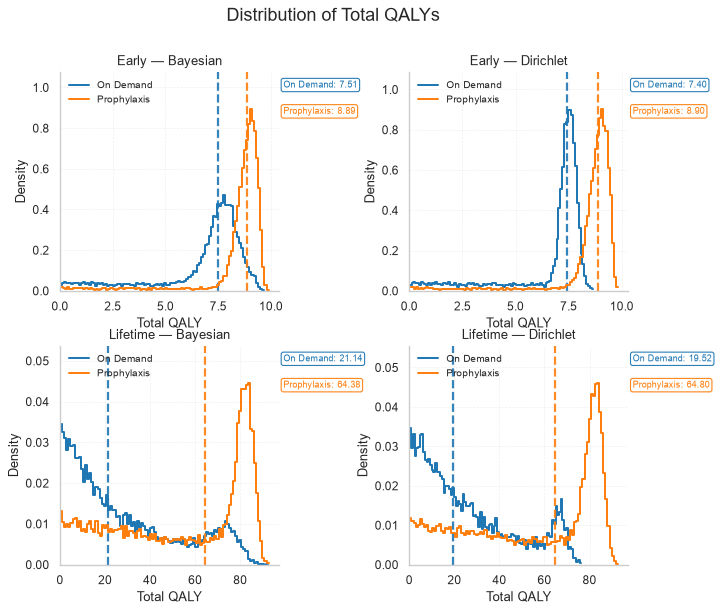

In [112]:
# QALY DISTRIBUTION


@apply_grid(
    row_name="time_horizon",
    col_name="sampling_method",
    row_values=["early", "lifetime"],
    col_values=["bayesian", "dirichlet"],
    dataframe=df.filter(~pl.col("extension").is_not_null()),
    title_formatter=lambda r, c: f"{r.capitalize()} — {c.capitalize()}",
)
def plot_qaly_distribution(
    ax,
    sub,
    row_value,
    col_value,
    **kwargs,
):

    stats_text = []

    for regime, color in palette.items():

        sub_r = sub.filter(pl.col("regime") == regime)
        median_qaly = sub_r["total_qaly"].median()

        stats_text.append(
            (
                f"{regime.replace('-', ' ').title()}: " f"{median_qaly:.2f}",
                color,
            )
        )

        sns.histplot(
            data=sub_r,
            x="total_qaly",
            bins=100,
            stat="density",
            element="step",
            fill=False,
            common_norm=False,
            linewidth=1.8,
            color=color,
            ax=ax,
            label=regime.replace("-", " ").title(),
        )

        ax.axvline(
            median_qaly,
            color=color,
            linestyle="--",
            linewidth=2,
            alpha=0.9,
        )

    text_y = 0.96

    for text, color in stats_text:

        ax.text(
            1.02,  # outside right side
            text_y,
            text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8,
            color=color,
            bbox=dict(
                facecolor="white",
                edgecolor=color,
                alpha=0.95,
                boxstyle="round,pad=0.25",
            ),
        )

        text_y -= 0.12

    ax.set_xlim(left=0)

    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.15)

    ax.set_xlabel("Total QALY")
    ax.set_ylabel("Density")

    ax.grid(
        alpha=0.2,
        linestyle="--",
        linewidth=0.6,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        frameon=False,
        fontsize=9,
        loc="upper left",
    )


fig, axes = plot_qaly_distribution()

fig.suptitle(
    "Distribution of Total QALYs",
    fontsize=16,
)

plt.show()

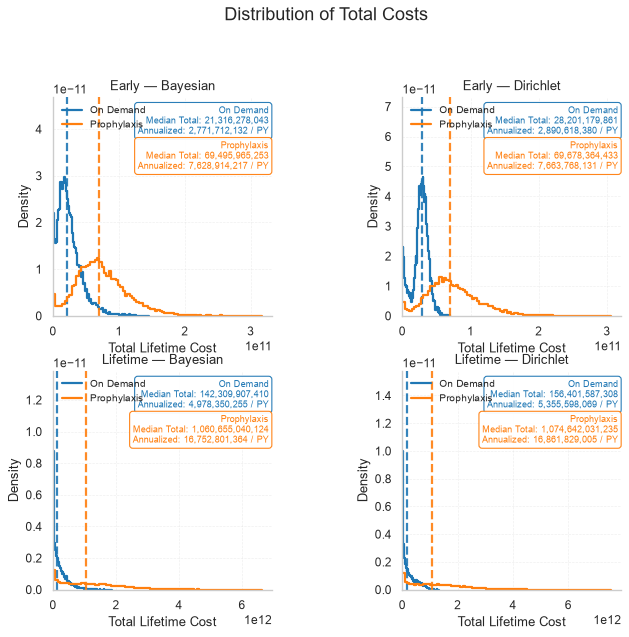

In [113]:
# COST DISTRIBUTION


@apply_grid(
    row_values=["early", "lifetime"],
    col_values=["bayesian", "dirichlet"],
    row_name="time_horizon",
    col_name="sampling_method",
    dataframe=df.filter(~pl.col("extension").is_not_null()),
    title_formatter=lambda r, c: f"{r.capitalize()} — {c.capitalize()}",
)
def plot_cost_distribution(
    ax,
    sub,
    row_value,
    col_value,
    **kwargs,
):

    annotation_y = [0.96, 0.80]
    for idx, (regime, color) in enumerate(palette.items()):

        sub_r = sub.filter(pl.col("regime") == regime)

        median_total_cost = sub_r["total_cost"].median()
        annualized_cost = (sub_r["total_cost"] / sub_r["person_years"]).mean()

        sns.histplot(
            data=sub_r,
            x="total_cost",
            bins=90,
            stat="density",
            element="step",
            fill=False,
            common_norm=False,
            linewidth=2,
            color=color,
            ax=ax,
            label=regime.replace("-", " ").title(),
        )

        # Median line
        ax.axvline(
            median_total_cost,
            color=color,
            linestyle="--",
            linewidth=2,
            alpha=0.9,
        )

        # Annotation
        ax.text(
            0.985,
            annotation_y[idx],
            (
                f"{regime.replace('-', ' ').title()}\n"
                f"Median Total: {median_total_cost:,.0f}\n"
                f"Annualized: {annualized_cost:,.0f} / PY"
            ),
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8,
            color=color,
            bbox=dict(
                facecolor="white",
                edgecolor=color,
                alpha=0.95,
                boxstyle="round,pad=0.35",
            ),
        )

    ax.set_xlim(left=0)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.5)

    ax.set_xlabel("Total Lifetime Cost")
    ax.set_ylabel("Density")

    ax.grid(
        alpha=0.20,
        linestyle="--",
        linewidth=0.6,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        frameon=False,
        fontsize=9,
        loc="upper left",
    )


fig, axes = plot_cost_distribution()

fig.suptitle(
    "Distribution of Total Costs",
    fontsize=16,
    y=1.02,
)

plt.show()

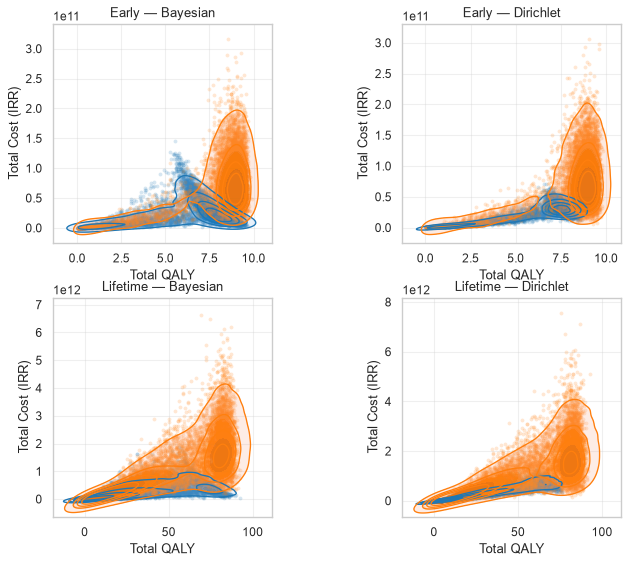

In [114]:
# KDE JOINT PLOT

cost_unit = "IRR"


@apply_grid(
    row_values=["early", "lifetime"],
    col_values=["bayesian", "dirichlet"],
    row_name="time_horizon",
    col_name="sampling_method",
    dataframe=df.filter(~pl.col("extension").is_not_null()),
    title_formatter=lambda r, c: f"{r.capitalize()} — {c.capitalize()}",
)
def plot_joint_density(
    ax,
    sub,
    row_value,
    col_value,
    **kwargs,
):
    horizon = row_value
    dist = col_value

    for regime, color in palette.items():

        sub_r = sub.filter(pl.col("regime") == regime)

        # Scatter
        sns.scatterplot(
            data=sub_r,
            x="total_qaly",
            y="total_cost",
            ax=ax,
            color=color,
            s=12,
            alpha=0.18,
            edgecolor=None,
            linewidth=0,
            rasterized=True,
        )

        # Filled KDE
        sns.kdeplot(
            data=sub_r,
            x="total_qaly",
            y="total_cost",
            ax=ax,
            fill=True,
            levels=4,
            thresh=0.05,
            alpha=0.22,
            color=color,
            bw_adjust=1,
        )

        # KDE outlines
        sns.kdeplot(
            data=sub_r,
            x="total_qaly",
            y="total_cost",
            ax=ax,
            fill=False,
            levels=5,
            linewidths=1.2,
            color=color,
            bw_adjust=1,
        )

    ax.set_xlabel("Total QALY")
    ax.set_ylabel(f"Total Cost ({kwargs['cost_unit']})")


fig, axes = plot_joint_density(cost_unit=cost_unit)

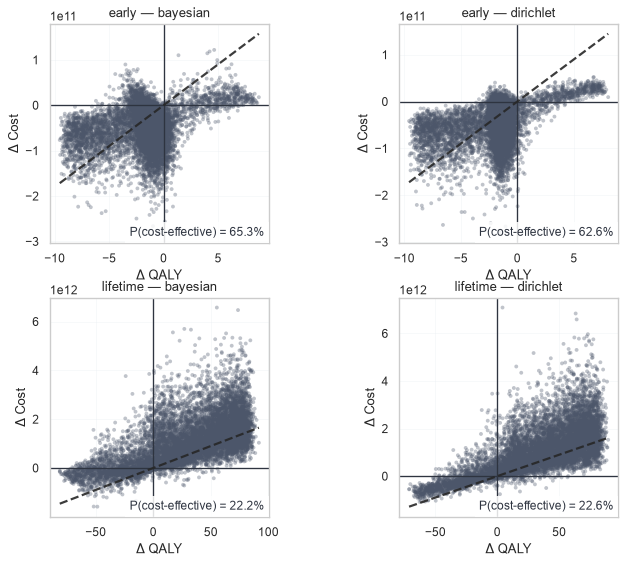

In [115]:
# Cost-effectiveness plane with probability CE annotation

POINT_COLOR = "#4C566A"
WTP_COLOR = "#272727"
AXIS_COLOR = "#2E3440"
GRID_COLOR = "#E5E9F0"


@apply_grid(
    row_values=["early", "lifetime"],
    col_values=["bayesian", "dirichlet"],
    row_name="time_horizon",
    col_name="sampling_method",
    dataframe=df.filter(~pl.col("extension").is_not_null()),
)
def plot_ce_plane_grid(ax, sub, row_value, col_value, i, j):

    scenarios = sub["scenario"].unique().to_list()

    if len(scenarios) < 2:
        ax.text(0.5, 0.5, "Need ≥ 2 scenarios", ha="center", va="center")
        ax.set_axis_off()
        return

    base, comp = scenarios[:2]

    base_df = sub.filter(pl.col("scenario") == base)
    comp_df = sub.filter(pl.col("scenario") == comp)

    delta_cost = (comp_df["total_cost"] - base_df["total_cost"]).to_numpy()
    delta_qaly = (comp_df["total_qaly"] - base_df["total_qaly"]).to_numpy()

    nmb_base = base_df["total_qaly"] * WTP - base_df["total_cost"]
    nmb_comp = comp_df["total_qaly"] * WTP - comp_df["total_cost"]

    delta_nmb = nmb_comp.to_numpy() - nmb_base.to_numpy()

    prob_ce = float((delta_nmb > 0).mean())

    ax.scatter(
        delta_qaly,
        delta_cost,
        alpha=0.35,
        s=12,
        color=POINT_COLOR,
        edgecolor="none",
    )

    ax.axhline(0, linewidth=1.2, color=AXIS_COLOR)
    ax.axvline(0, linewidth=1.2, color=AXIS_COLOR)

    x = np.linspace(delta_qaly.min(), delta_qaly.max(), 100)
    ax.plot(
        x,
        x * WTP,
        linestyle="--",
        linewidth=2,
        color=WTP_COLOR,
        alpha=0.9,
    )

    ax.grid(True, color=GRID_COLOR, linewidth=0.8)

    ax.set_xlabel("Δ QALY")
    ax.set_ylabel("Δ Cost")
    ax.set_title(f"{row_value} | {col_value}\n{comp} vs {base}")

    ax.text(
        0.98,
        0.02,
        f"P(cost-effective) = {prob_ce:.1%}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=11,
        color=AXIS_COLOR,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
    )


fig, axes = plot_ce_plane_grid()


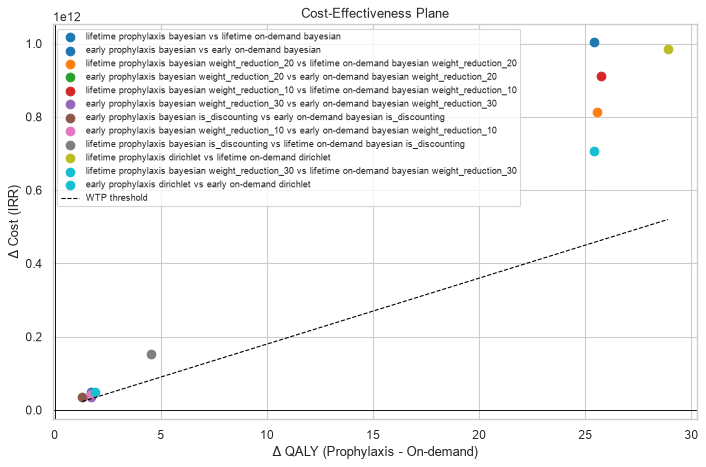

In [116]:
# Combined CE plane with all comparisons and WTP threshold

fig, ax = plt.subplots(figsize=(9, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(icer_nmb_df)))  # type: ignore

for i, row in enumerate(icer_nmb_df.iter_rows(named=True)):
    ax.scatter(
        row["Δ QALY"], row["Δ cost"], color=colors[i], s=60, label=row["comparison"]
    )

# WTP threshold line
x_vals = np.linspace(icer_nmb_df["Δ QALY"].min(), icer_nmb_df["Δ QALY"].max(), 200)  # type: ignore

ax.plot(x_vals, x_vals * WTP, "--", color="black", linewidth=1, label="WTP threshold")

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)

ax.set_xlabel("Δ QALY (Prophylaxis - On-demand)")
ax.set_ylabel(f"Δ Cost ({cost_unit})")
ax.set_title("Cost-Effectiveness Plane")

ax.legend(fontsize=8, frameon=True)

plt.tight_layout()
plt.show()

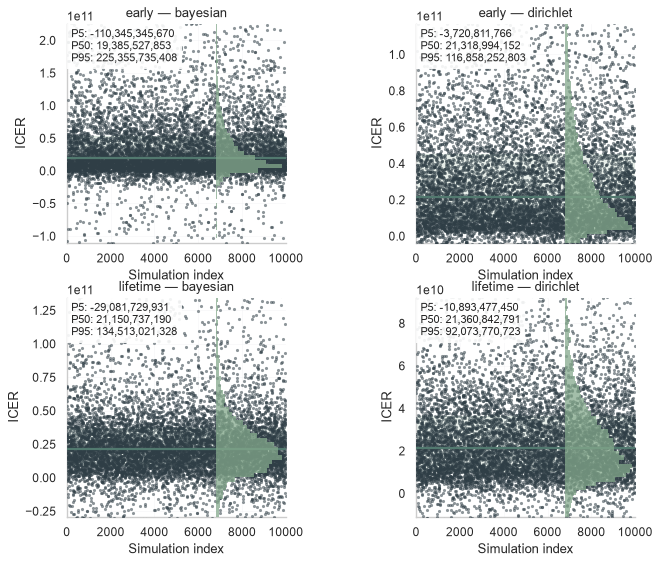

In [117]:
# ICER DISTRIBUTION WITH INSET HISTOGRAM

BLUE = "#2F3E46"
EDGE = "#52796F"
HIST = "#84A98C"
GRID = "#E9ECEF"


@apply_grid(
    row_values=["early", "lifetime"],
    col_values=["bayesian", "dirichlet"],
    row_name="time_horizon",
    col_name="sampling_method",
    dataframe=df.filter(~pl.col("extension").is_not_null()),
)
def plot_icer_distribution(ax, sub, row_value, col_value, i, j):

    scenarios = sub["scenario"].unique().to_list()
    base, comp = scenarios[:2]

    base_df = sub.filter(pl.col("scenario") == base)
    comp_df = sub.filter(pl.col("scenario") == comp)

    dc = (comp_df["total_cost"] - base_df["total_cost"]).to_numpy()
    dq = (comp_df["total_qaly"] - base_df["total_qaly"]).to_numpy()

    valid = np.isfinite(dc) & np.isfinite(dq) & (dq != 0)
    icer = dc[valid] / dq[valid]

    if icer.size == 0:
        ax.text(0.5, 0.5, "No valid ICERs", ha="center", va="center")
        ax.set_axis_off()
        return

    q5, q25, q50, q75, q95 = np.percentile(icer, [5, 25, 50, 75, 95])
    clipped = icer[(icer >= q5) & (icer <= q95)]

    x = np.arange(len(icer))

    ax.scatter(x, icer, s=8, color=BLUE, alpha=0.55, linewidths=0, zorder=3)

    ax.axhspan(q25, q75, color=HIST, alpha=0.18, zorder=1)
    ax.axhline(q50, color=EDGE, linewidth=2.0, zorder=4)

    ax.set_xlim(0, len(icer))
    ax.set_ylim(q5, q95)

    ax.set_xlabel("Simulation index")
    ax.set_ylabel("ICER")
    ax.set_title(f"{row_value} | {col_value}\n{comp} vs {base}", pad=10)

    ax.grid(True, color=GRID, linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    hist_ax = inset_axes(
        ax,
        width="32%",
        height="100%",
        loc="upper right",
        borderpad=0,
    )

    hist_ax.hist(
        clipped,
        bins=50,
        orientation="horizontal",
        color=HIST,
        alpha=0.75,
        edgecolor="none",
    )

    hist_ax.set_ylim(ax.get_ylim())

    hist_ax.set_xticks([])
    hist_ax.set_yticks([])
    hist_ax.set_frame_on(False)

    ax.text(
        0.02,
        0.98,
        f"P5: {q5:,.0f}\nP50: {q50:,.0f}\nP95: {q95:,.0f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.9),
    )


fig, axes = plot_icer_distribution()


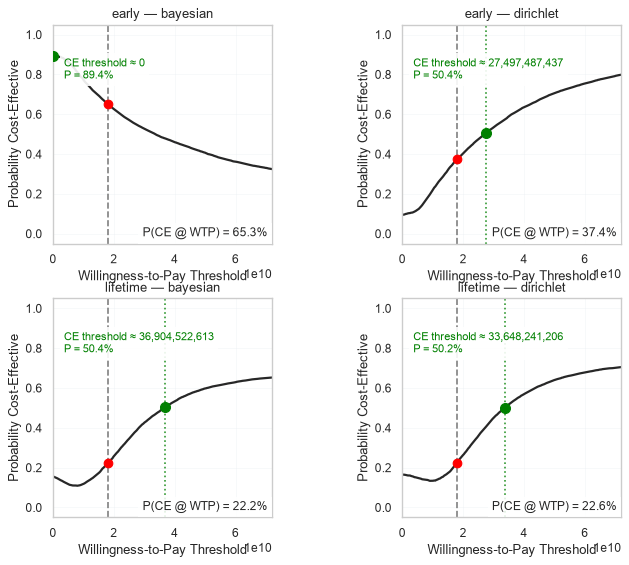

In [ ]:
# CEAC PLOT WITH THRESHOLD ANNOTATION

POINT_COLOR = "#4C566A"
LINE_COLOR = "#272727"
GRID_COLOR = "#E5E9F0"


@apply_grid(
    row_values=["early", "lifetime"],
    col_values=["bayesian", "dirichlet"],
    row_name="time_horizon",
    col_name="sampling_method",
    dataframe=df.filter(~pl.col("extension").is_not_null()),
)
def plot_ceac_grid(ax, sub, row_value, col_value, i, j):

    scenarios = sub["scenario"].unique().to_list()

    if len(scenarios) < 2:
        ax.text(0.5, 0.5, "Need ≥ 2 scenarios", ha="center", va="center")
        ax.set_axis_off()
        return

    base, comp = scenarios[:2]

    base_df = sub.filter(pl.col("scenario") == base)
    comp_df = sub.filter(pl.col("scenario") == comp)

    max_threshold = WTP * 4
    X = np.linspace(0, max_threshold, 200)

    Y = []

    for wtp in X:
        nmb_base = base_df["total_qaly"] * wtp - base_df["total_cost"]
        nmb_comp = comp_df["total_qaly"] * wtp - comp_df["total_cost"]
        prob_ce = (nmb_comp.to_numpy() > nmb_base.to_numpy()).mean()
        Y.append(prob_ce)

    Y = np.array(Y)

    crossing_idx = np.where(Y >= 0.5)[0]

    if len(crossing_idx) > 0:
        ce_threshold = X[crossing_idx[0]]
        ce_prob_at_threshold = Y[crossing_idx[0]]
    else:
        ce_threshold = None

    nmb_base_wtp = base_df["total_qaly"] * WTP - base_df["total_cost"]
    nmb_comp_wtp = comp_df["total_qaly"] * WTP - comp_df["total_cost"]

    current_prob = (nmb_comp_wtp.to_numpy() > nmb_base_wtp.to_numpy()).mean()

    sns.set_theme(style="whitegrid")

    ax.plot(X, Y, linewidth=2, color=LINE_COLOR)

    ax.axvline(WTP, color="gray", linestyle="--", linewidth=1.5)

    ax.scatter(WTP, current_prob, color="red", s=60, zorder=5)

    if ce_threshold is not None:

        ax.scatter(
            ce_threshold,
            ce_prob_at_threshold,  # type: ignore
            color="green",
            s=80,
            zorder=6,
        )

        ax.axvline(
            ce_threshold,
            color="green",
            linestyle=":",
            linewidth=1.5,
            alpha=0.8,
        )

        ax.annotate(
            f"CE threshold ≈ {ce_threshold:,.0f}\nP = {ce_prob_at_threshold:.1%}",  # type: ignore
            xy=(ce_threshold, ce_prob_at_threshold),  # type: ignore
            xytext=(0.05, 0.85),
            textcoords="axes fraction",
            fontsize=10,
            color="green",
            bbox=dict(facecolor="white", alpha=0.9, edgecolor="none"),
            ha="left",
            va="top",
        )

    ax.set_xlabel("Willingness-to-Pay Threshold")
    ax.set_ylabel("Probability Cost-Effective")
    ax.set_title(f"{row_value} | {col_value}\n{comp} vs {base}")

    ax.set_xlim(0, max_threshold)
    ax.set_ylim(-0.05, 1.05)

    ax.grid(True, color=GRID_COLOR, linewidth=0.8)

    ax.text(
        0.98,
        0.02,
        f"P(CE @ WTP) = {current_prob:.1%}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=11,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
    )


fig, axes = plot_ceac_grid()

In [ ]:
# ICER ANALYSIS WITH PARAMETRIC FITTING + THRESHOLD
# Rendered as a 4x3 grid (one panel per scenario pair) so the whole
# analysis fits on a single notebook page.


def _short_pair_label(od: str, pro: str) -> str:
    """Compact 2-line label for a pair of scenario names.

    The two scenarios differ only in the regime token (e.g.
    ``on-demand`` vs ``prophylaxis``); every other token is
    shared. Return the common tokens on the first line and the
    regime transition on the second.
    """
    od_parts = od.split()
    pro_parts = pro.split()
    common = [p for p, q in zip(od_parts, pro_parts) if p == q]
    common_str = " / ".join(common)
    od_regime = od_parts[1].replace("-", " ").title() if len(od_parts) > 1 else ""
    pro_regime = pro_parts[1].replace("-", " ").title() if len(pro_parts) > 1 else ""
    return f"{common_str}\n{pro_regime} → {od_regime}"


# PARAMETRIC MODELS
def sat_exp(x, a, b, c):
    """Saturating exponential model"""
    return a * (1 - np.exp(-b * x)) + c


def logistic(x, L, k, x0, c):
    """Logistic / sigmoidal model"""
    return L / (1 + np.exp(-k * (x - x0))) + c


# METRICS
def r2_score(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - (ss_res / ss_tot)


def aic(y, yhat, k):
    n = len(y)
    rss = np.sum((y - yhat) ** 2)
    return n * np.log(rss / n + 1e-12) + 2 * k


def bootstrap_icer(od: pl.DataFrame, pro: pl.DataFrame, B: int = 2000, seed: int = 42):
    """Bootstrap ICER estimator"""
    np.random.seed(seed)
    n = min(len(od), len(pro))
    icers = np.full(B, np.nan)

    od_cost = od["total_cost"].sum()
    od_qaly = od["total_qaly"].sum()
    pro_cost = pro["total_cost"].to_numpy()
    pro_qaly = pro["total_qaly"].to_numpy()

    for i in range(B):
        idx = np.random.randint(0, len(pro), size=n)
        d_cost = pro_cost[idx].sum() - od_cost
        d_qaly = pro_qaly[idx].sum() - od_qaly
        if abs(d_qaly) > 1e-9:
            icers[i] = d_cost / d_qaly

    return np.nanmean(icers), np.nanstd(icers)


def find_threshold(x, y, wtp):
    """Find x where curve crosses WTP (linear interpolation)"""
    diff = y - wtp
    sign_changes = np.where(np.diff(np.sign(diff)))[0]

    if len(sign_changes) == 0:
        return None

    i = sign_changes[0]
    x0, x1 = x[i], x[i + 1]
    y0, y1 = y[i], y[i + 1]

    return x0 + (wtp - y0) * (x1 - x0) / (y1 - y0)


# Pre-compute results for every pair, then plot a single 4x3 grid.
pair_results = []
for od_name, pro_name in pairs:
    od_df = df.filter(pl.col("scenario") == od_name)
    pro_df = df.filter(pl.col("scenario") == pro_name)

    if od_df.is_empty() or pro_df.is_empty():
        print(f"Skipping {od_name} vs {pro_name}: no data")
        continue

    print("=" * 90)
    print(f"ICER ANALYSIS: {pro_name} vs {od_name}")
    print("=" * 90)

    max_abr = int(od_df["sampled_abr"].max() or 0)
    icer_mean = {}
    icer_std = {}

    for t in range(max_abr + 1):
        od_sel = od_df.filter(pl.col("sampled_abr") >= t)
        if len(od_sel) < 5:
            continue

        mean_icer, std_icer = bootstrap_icer(od_sel, pro_df, B=2000, seed=42 + t)
        icer_mean[t] = mean_icer
        icer_std[t] = std_icer

    if len(icer_mean) < 6:
        print("Not enough data points for robust analysis.")
        continue

    x = np.array(list(icer_mean.keys()))
    y = np.array(list(icer_mean.values()))
    yerr = np.array(list(icer_std.values()))

    ma = np.isfinite(y)
    x, y, yerr = x[ma], y[ma], yerr[ma]

    lowess_curve = lowess(y, x, frac=0.35, return_sorted=True)
    x_s = lowess_curve[:, 0]
    y_s = lowess_curve[:, 1]

    models = {}
    try:
        p0 = [np.max(y), 0.05, np.min(y)]
        params, _ = curve_fit(sat_exp, x, y, p0=p0, maxfev=20000)
        yhat = sat_exp(x, *params)
        models["sat_exp"] = {
            "params": params,
            "r2": r2_score(y, yhat),
            "aic": aic(y, yhat, k=3),
            "curve": sat_exp(x_s, *params),
        }
    except Exception:
        pass

    try:
        p0 = [np.max(y), 0.1, np.median(x), np.min(y)]
        params, _ = curve_fit(logistic, x, y, p0=p0, maxfev=20000)
        yhat = logistic(x, *params)
        models["logistic"] = {
            "params": params,
            "r2": r2_score(y, yhat),
            "aic": aic(y, yhat, k=4),
            "curve": logistic(x_s, *params),
        }
    except Exception:
        pass

    best_model = None
    if models:
        best_model = min(models.items(), key=lambda item: item[1]["aic"])

    abr_star = find_threshold(x_s, y_s, WTP)
    baseline_abr = od_df["sampled_abr"].mean()
    abr_reduction = max(0.0, baseline_abr - abr_star) if abr_star is not None else None

    print(f"WTP                        : {WTP:,.0f}")
    print(f"Baseline ABR (on-demand)   : {baseline_abr:.2f}")
    if abr_star is not None:
        print(f"Cost-effective ABR*        : {abr_star:.2f}")
        print(f"Required ABR reduction     : {abr_reduction:.2f}")
    else:
        print("No cost-effective threshold found within observed range.")

    if best_model:
        name, res = best_model
        print(
            f"Best parametric model      : {name} (R^2 = {res['r2']:.4f}, AIC = {res['aic']:.1f})"
        )

    pair_results.append(
        {
            "od_name": od_name,
            "pro_name": pro_name,
            "x": x,
            "y": y,
            "yerr": yerr,
            "x_s": x_s,
            "y_s": y_s,
            "best_model": best_model,
            "abr_star": abr_star,
            "baseline_abr": baseline_abr,
        }
    )

# 4x3 grid (or as close as needed). 12 pairs is the typical size but
# fall back to a smaller grid if fewer pairs produced results.
n_pairs = len(pair_results)
if n_pairs == 0:
    print("No pairs to plot.")
else:
    n_cols = 3 if n_pairs >= 9 else (2 if n_pairs >= 4 else 1)
    n_rows = (n_pairs + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.0 * n_cols, 3.4 * n_rows),
        squeeze=False,
    )

    for k, res in enumerate(pair_results):
        ax = axes[k // n_cols][k % n_cols]

        ax.errorbar(
            res["x"],
            res["y"],
            yerr=res["yerr"],
            fmt="o",
            markersize=4,
            alpha=0.65,
            capsize=2,
            capthick=0.8,
            elinewidth=0.8,
        )

        ax.plot(
            res["x_s"],
            res["y_s"],
            linewidth=2.0,
            color="#1f77b4",
            label="LOWESS",
        )

        if res["best_model"]:
            name, m = res["best_model"]
            ax.plot(
                res["x_s"],
                m["curve"],
                linestyle="--",
                linewidth=1.4,
                color="#ff7f0e",
                label=f"{name}",
            )

        ax.axhline(
            WTP,
            linestyle="--",
            linewidth=1.4,
            color="darkred",
        )

        if res["abr_star"] is not None:
            ax.axvline(
                res["abr_star"],
                linestyle="--",
                linewidth=1.4,
                color="#d62728",
            )

        # Compact 2-line subplot title (was: full scenario name pair)
        ax.set_title(
            _short_pair_label(res["od_name"], res["pro_name"]),
            fontsize=8,
            wrap=True,
        )
        ax.set_xlabel("ABR threshold", fontsize=8)
        ax.set_ylabel("ICER", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.25)

    # Hide any unused panels.
    for k in range(n_pairs, n_rows * n_cols):
        axes[k // n_cols][k % n_cols].set_axis_off()

    fig.suptitle(
        "ICER vs ABR threshold - LOWESS + parametric fit (per scenario pair)",
        fontsize=12,
    )
    # Reserve 7% of figure height at the top for the suptitle and
    # the 2-line subplot titles; tight_layout would otherwise let
    # them collide.
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()

ICER ANALYSIS: lifetime prophylaxis bayesian vs lifetime on-demand bayesian
WTP                        : 18,000,000,000
Baseline ABR (on-demand)   : 22.58
No cost-effective threshold found within observed range.
Best parametric model      : logistic (R^2 = 0.9958, AIC = 4091.5)
ICER ANALYSIS: early prophylaxis bayesian vs early on-demand bayesian
WTP                        : 18,000,000,000
Baseline ABR (on-demand)   : 22.58
Cost-effective ABR*        : 16.84
Required ABR reduction     : 5.73
Best parametric model      : logistic (R^2 = 0.9970, AIC = 4148.7)
ICER ANALYSIS: lifetime prophylaxis bayesian weight_reduction_20 vs lifetime on-demand bayesian weight_reduction_20
WTP                        : 18,000,000,000
Baseline ABR (on-demand)   : 22.58
Cost-effective ABR*        : 53.37
Required ABR reduction     : 0.00
Best parametric model      : logistic (R^2 = 0.9970, AIC = 4009.1)
ICER ANALYSIS: early prophylaxis bayesian weight_reduction_20 vs early on-demand bayesian weight_reductio